In [13]:
import mdtraj as md
import numpy as np

from tqdm import tqdm
from glob import glob

from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter

from sklearn.cross_decomposition import CCA

In [2]:
def sci_notation_no_sigfigs(number, pos):
    a, b = f"{number:.0e}".split("e")
    b = int(b)
    if b == 0:
        return "0"
    return f"${a} \, \mathrm{{x}} \, 10^{{{b}}}$"


def sci_notation_one_sigfig(number, pos):
    a, b = f"{number:.1e}".split("e")
    b = int(b)
    if b == 0:
        return "0"
    return f"${a} \, \mathrm{{x}} \, 10^{{{b}}}$"

## Load MD and Crystal data

In [3]:
ATOM_SELECTION = '(element != H) and is_protein and (resi < 303) and (resi > 1)'

def load_pdbs(glob_pattern):
    
    crystals = None
    crystal_chis = []

    first = True
    files_to_load = sorted(glob(glob_pattern))
    
    for pdb in tqdm(files_to_load):

        try:
            
            trj = md.load_pdb(pdb)
            idx = trj.top.select(ATOM_SELECTION)
            trj = trj.atom_slice(idx)

            chi_atoms, chi = md.compute_chi1(trj)
            crystal_chis.extend(chi)

            if first:
                chi_idx = [ trj.topology.atom(int(a)).residue.index for a in chi_atoms[:,0] ]
                first = False

            idx = trj.top.select('name == CA')
            trj = trj.atom_slice(idx)

            if crystals:
                crystals = crystals.join(trj, check_topology=False)
            else:
                crystals = trj

        except Exception as exptn:
            print(trj.xyz.shape)
            print(crystals.xyz.shape)
            print("something went wrong", pdb, exptn)

    crystals = crystals.center_coordinates()
    crystal_chis = np.array(crystal_chis)
    
    return crystals, crystal_chis

In [4]:
SUBSAMPLE     = 10 # for MD simulation, 1 = 1 ns

In [5]:
crystals, crystal_chis = load_pdbs('../../allostery/selected_dataset_archive_2024-08-07/pdb/*.pdb')

100%|██████████| 1146/1146 [04:51<00:00,  3.93it/s]


In [6]:
# each dcd file is 1000 frames with 1ns spacing between frames

prefix = '/asap3/petra3/gpfs/p11/2020/data/11009999/shared/mdsim/DESRES-Trajectory_sarscov2-10880334-no-water-no-ion-glueCA'
md_files = sorted(glob(prefix + '/sarscov2-10880334-no-water-no-ion-glueCA/*.dcd'))

top_path = prefix + '/system_nowat.pdb'

md_sim = None
md_chis = []

for f in tqdm(md_files):

    t = md.load(f, top=top_path)[::SUBSAMPLE]

    idx = t.top.select(ATOM_SELECTION)
    t   = t.atom_slice(idx)
    
    _, chis = md.compute_chi1(t)
    md_chis.extend(chis)

    idx = t.top.select('name == CA')
    t   = t.atom_slice(idx)

    if md_sim == None:
        md_sim = t
    else:
        md_sim += t

md_sim = md_sim.center_coordinates()
md_chis = np.array(md_chis)

100%|██████████| 100/100 [01:02<00:00,  1.59it/s]


In [7]:
prefix = '/asap3/petra3/gpfs/p11/2020/data/11009999/shared/diamond_05-May-2020/'
diamond, diamond_chis = load_pdbs(prefix + '*.pdb')

 57%|█████▋    | 60/105 [00:12<00:09,  4.88it/s]

(1, 299, 3)
(59, 301, 3)
something went wrong /asap3/petra3/gpfs/p11/2020/data/11009999/shared/diamond_05-May-2020/Mpro-x1187_0.pdb Number of atoms in self (301) is not equal to number of atoms in other


100%|██████████| 105/105 [00:21<00:00,  4.91it/s]


In [8]:
# phenix ensembles

phenix_ensembles = []
ensemble_pdb_paths = glob('/gpfs/cfel/user/tjlane/mpro/allostery/ensemble_refinements/four_datasets/*/*.updated_ensemble.nowater.pdb')

for ensemble_pdb_path in ensemble_pdb_paths:
    ensemble, _ = load_pdbs(ensemble_pdb_path)
    phenix_ensembles.append(ensemble)

100%|██████████| 1/1 [00:05<00:00,  5.30s/it]


In [9]:
print(crystals.xyz.shape, crystal_chis.shape)
print(md_sim.xyz.shape,   md_chis.shape)
print(diamond.xyz.shape,  diamond_chis.shape)
print([ensemble.xyz.shape for ensemble in phenix_ensembles])

(1146, 301, 3) (1146, 259)
(10000, 301, 3) (10000, 259)
(104, 301, 3) (105,)
[(67, 301, 3), (29, 301, 3), (50, 301, 3), (50, 301, 3)]


In [10]:
active_site_residues = np.array([41, 49, 143, 144, 145, 163, 164, 165, 166, 167, 187, 188, 189, 190, 191, 192]) - 3

residues = list(crystals.top.residues)
asr_names = [ residues[asr].name + str(residues[asr].resSeq) for asr in active_site_residues ]

print(asr_names)

['HIS41', 'MET49', 'GLY143', 'SER144', 'CYS145', 'HIS163', 'HIS164', 'MET165', 'GLU166', 'LEU167', 'ASP187', 'ARG188', 'GLN189', 'THR190', 'ALA191', 'GLN192']


## canonical correlation

In [18]:
def canonical_correlation_analysis(xyz):
    """
    CCA finds the vectors a and b that maximze corr(ax, by)
    
    here, x and y are samples each atom's xyz position 3-vectors
    
    this function returns the coefficients of determination R^2 for each atom pair i,j
    """
    
    cca = np.zeros((xyz.shape[1], xyz.shape[1]))
    
    for atom_index_i in range(xyz.shape[1]):
        for atom_index_j in range(atom_index_i, xyz.shape[1]):
            
            x = xyz[:,atom_index_i,:]
            y = xyz[:,atom_index_j,:]
            
            r2 = CCA(n_components=1).fit(x, y).score(x, y)
            
            cca[atom_index_i, atom_index_j] = r2
            cca[atom_index_j, atom_index_i] = r2
    
    return cca

In [ ]:
S_xtal = canonical_correlation_analysis(crystals.xyz)
S_md   = canonical_correlation_analysis(md_sim.xyz)
S_dmnd = canonical_correlation_analysis(diamond.xyz)
S_ensb = [canonical_correlation_analysis(ensemble.xyz) for ensemble in phenix_ensembles]

In [ ]:
#err_S_xtal = bootstrap_iso_cov(crystals.xyz, n_samples=1000)

In [ ]:
# title, matrix to plot, filename to save
phenix_ensemble_datasets = [
    ('phenix ensemble %d' % (ip+1), S_ensb[ip], f"ensemble_{Path(dataset_name).name.split('.')[0]}") for ip, dataset_name in enumerate(ensemble_pdb_paths)
]
phenix_ensemble_datasets

In [ ]:
ticks = np.arange(0, crystals.xyz.shape[1], 100)
cmap = 'viridis'

# title, matrix to plot, filename to save
datasets = [
    (r'ligand-free M$^\mathrm{pro}$ crystals', S_xtal, "cov_xtal_ensemble"),
    ('DESRES Simulation', S_md[:S_xtal.shape[0],:S_xtal.shape[1]], "cov_md"),
    ('Diamond Frag. Screen', S_dmnd, "cov_dmnd_ensemble"),
] + phenix_ensemble_datasets


# how much to zoom colorbar
scales = [0.7,] * 7

# datasets = [(r'ligand-free M$^\mathrm{pro}$ crystals', S_xtal, "cca_xtal_ensemble"),]
# scales = [0.7,]

for i_d, dataset in enumerate(datasets):

    figsize = (3.5,3.5)

    fig = plt.figure(figsize=figsize)
    ax1 = plt.subplot(111)

    ax1.set_title(dataset[0], 
                  fontweight='bold', fontsize=10)
    

    print(dataset[1].max())
    im = ax1.imshow(
        dataset[1],
        cmap=cmap, 
        vmin=0,
        vmax=scales[i_d],
    )

    ax1.set_xticks(ticks)
    ax1.set_xticklabels([str(int(t)) for t in ticks])
    ax1.set_yticks(ticks)
    ax1.set_yticklabels([str(int(t)) for t in ticks])
    ax1.set_xlabel('Residue Index')
    ax1.set_ylabel('Residue Index')
    
    ax1.set_xticks([])
    ax1.set_yticks([])

    cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
    
    cbar.set_label('CCA R$^2$ ($\AA^2$)', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.savefig(f'./figures/covariance_matrices/cca_{dataset[2]}.pdf')
    plt.show()

## View correlation projected on active site

In [30]:
mu_xtal  = np.abs(S_xtal[active_site_residues,:]).mean(0)
std_xtal = np.abs(S_xtal[active_site_residues,:]).std(0)

# err_mu_xtal = np.sqrt(np.mean(np.square(err_S_xtal[active_site_residues,:]), axis=0)) # 1-sigma

# mu_md  = np.abs(S_md[active_site_residues,:S_xtal.shape[0]]).mean(0)
# std_md = np.abs(S_md[active_site_residues,:S_xtal.shape[0]]).std(0)

# mu_dmnd  = np.abs(S_dmnd[active_site_residues,:S_xtal.shape[0]]).mean(0)
# std_dmnd = np.abs(S_dmnd[active_site_residues,:S_xtal.shape[0]]).std(0)

# mu_vaga  = np.abs(S_dmnd[active_site_residues,:S_xtal.shape[0]]).mean(0)
# std_vaga = np.abs(S_dmnd[active_site_residues,:S_xtal.shape[0]]).std(0)

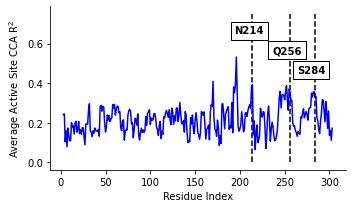

In [48]:
res_idx = np.arange(S_xtal.shape[0]) + 3

plt.figure(figsize=(5,3))

ax1 = plt.subplot(111)

ax1.plot(res_idx, mu_xtal, color='b')

ax1.set_xlabel(r'Residue Index')
ax1.set_ylabel(r'Average Active Site CCA R$^2$')

# interesting
ymin = 0.0
ymax = 0.75
y_shift = 0.1

bbox = dict(facecolor='white', edgecolor='black')
ax1.text(194, ymax - y_shift, 'N214', weight='bold', bbox=bbox)
ax1.text(236, ymax - 2*y_shift, 'Q256', weight='bold', bbox=bbox)
ax1.text(264, ymax - 3*y_shift, 'S284', weight='bold', bbox=bbox)

ax1.vlines(214, ymin, ymax, linestyles="--")
ax1.vlines(256, ymin, ymax, linestyles="--")
ax1.vlines(284, ymin, ymax, linestyles="--")

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

    
plt.tight_layout()
plt.savefig('figures/cca_to_active.pdf')
plt.show()